# 05 — Current injection patterns

**Task 5:** with 16 electrodes, compare the adjacent, opposite and skip-4 injection patterns.
**Task 6:** pull everything together and summarise what each method and pattern is good and bad at.

---

So far every simulation has injected current between neighbouring electrodes. That is only one
option. The pattern is set by how far apart the two current-carrying electrodes are:

| pattern | current goes between | gap |
|---|---|---|
| adjacent | electrode 0 and 1 | 1 |
| skip-4 | electrode 0 and 5 | 5 |
| opposite | electrode 0 and 8 | 8 |

**A note on "skip-4":** the name is used in two different ways in the literature. Here it means
4 electrodes are skipped *between* the pair, so the gap is 5 — which also makes "adjacent" the same
as "skip-0". Some authors instead use skip-4 to mean a gap of 4.

In all three cases the voltages are read between neighbouring electrodes, so the only thing changing
is where the current goes in.

In [1]:
import os, sys, time, warnings
from pathlib import Path

# Find pyEIT: either installed, or via the PYEIT_PATH environment variable.
try:
    import pyeit
except ImportError:
    for folder in filter(None, [os.environ.get("PYEIT_PATH"), "../pyEIT", "./pyEIT"]):
        if (Path(folder) / "pyeit").is_dir():
            sys.path.insert(0, str(Path(folder).resolve())); break
    import pyeit

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eit_helpers as eit

eit.use_project_style()
figures = Path("figures"); figures.mkdir(exist_ok=True)
tables = Path("results"); tables.mkdir(exist_ok=True)

print(f"{eit.NUMBER_OF_ELECTRODES} electrodes, background conductivity "
      f"{eit.BACKGROUND_CONDUCTIVITY}, images {eit.IMAGE_SIZE}x{eit.IMAGE_SIZE}")

16 electrodes, background conductivity 1.0, images 64x64


In [2]:
fine_mesh, coarse_mesh = eit.build_meshes()
patterns = list(eit.INJECTION_PATTERNS)
setups = {pattern: eit.build_measurement_setup(pattern) for pattern in patterns}

pd.DataFrame([dict(pattern=eit.PATTERN_NAMES[pattern],
                   injections=setups[pattern].n_exc,
                   readings_per_frame=setups[pattern].n_meas)
              for pattern in patterns])

,pattern,injections,readings_per_frame
0,adjacent (gap 1),16,208
1,opposite (gap 8),16,192
2,skip-4 (gap 5),16,192


All three take 16 injections and give a similar number of readings, so no pattern gets more data
than the others. Any difference has to come from *what* those readings tell us.

## Where each pattern can see

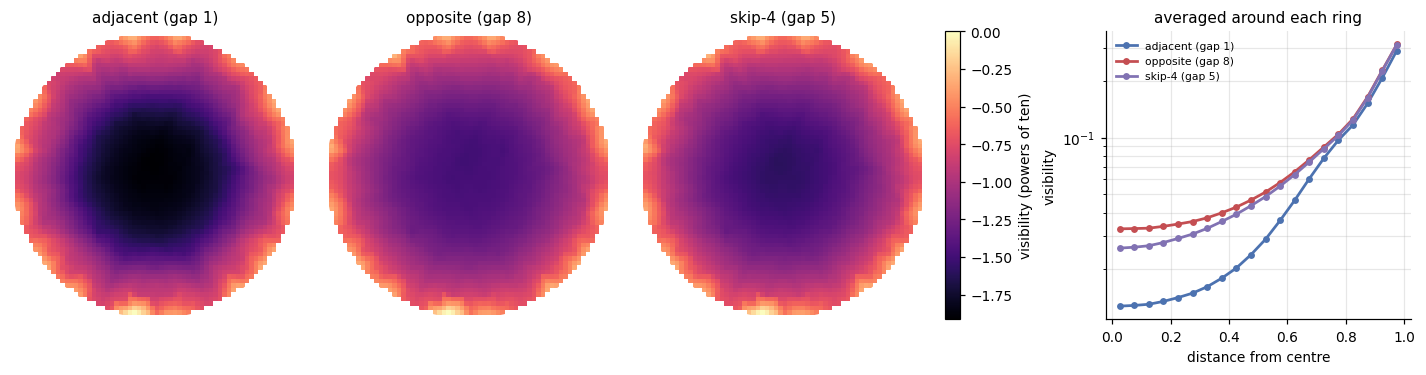

,pattern,edge_over_centre
0,adjacent (gap 1),22.8
1,opposite (gap 8),9.6
2,skip-4 (gap 5),12.1


In [3]:
sensitivity_maps = {pattern: eit.sensitivity_map(coarse_mesh, setups[pattern])
                    for pattern in patterns}

figure, axes = plt.subplots(1, 4, figsize=(13, 3.3), constrained_layout=True)
darkest = min(np.nanmin(np.log10(picture)) for picture in sensitivity_maps.values())
for axis, pattern in zip(axes, patterns):
    drawn = axis.imshow(np.log10(sensitivity_maps[pattern]), origin="lower",
                        extent=eit.IMAGE_EXTENT, cmap="magma", vmin=darkest, vmax=0)
    axis.add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=0.8, color="w"))
    axis.set_aspect("equal"); axis.set_xticks([]); axis.set_yticks([])
    for edge in axis.spines.values():
        edge.set_visible(False)
    axis.set_title(eit.PATTERN_NAMES[pattern])
figure.colorbar(drawn, ax=axes[:3].tolist(), fraction=0.03, pad=0.02,
                label="visibility (powers of ten)")

pixel_positions = np.linspace(-1, 1, eit.IMAGE_SIZE)
grid_x, grid_y = np.meshgrid(pixel_positions, pixel_positions)
distance_from_centre = np.hypot(grid_x, grid_y)
ring_edges = np.linspace(0, 1, 21)
ring_centres = 0.5 * (ring_edges[:-1] + ring_edges[1:])

uniformity_rows = []
for pattern in patterns:
    ring_average = np.array([
        np.nanmean(sensitivity_maps[pattern][(distance_from_centre >= inner)
                                             & (distance_from_centre < outer)])
        for inner, outer in zip(ring_edges[:-1], ring_edges[1:])])
    axes[3].semilogy(ring_centres, ring_average, marker="o", ms=3.5, lw=1.8,
                     color=eit.PATTERN_COLOURS[pattern], label=eit.PATTERN_NAMES[pattern])
    uniformity_rows.append(dict(pattern=eit.PATTERN_NAMES[pattern],
                                edge_over_centre=round(ring_average[-1] / ring_average[0], 1)))
axes[3].set_xlabel("distance from centre"); axes[3].set_ylabel("visibility")
axes[3].set_title("averaged around each ring")
axes[3].legend(fontsize=7); axes[3].grid(alpha=0.3, which="both")
figure.savefig(figures / "05_sensitivity.png")
plt.show()

uniformity = pd.DataFrame(uniformity_rows)
uniformity.to_csv(tables / "05_uniformity.csv", index=False)
uniformity

The `edge_over_centre` column says how many times less visible the middle of the tank is than the
edge. Adjacent injection is the most lopsided by a good margin; opposite is the most even, with
skip-4 close behind. That matches the current-path pictures back in notebook 01.

## How much signal each pattern produces

In [4]:
OBJECT_RADIUS = 0.15
test_positions = [0.0, 0.45, 0.65]

signal_rows, measurements = [], {}
for distance in test_positions:
    tank = eit.add_objects(fine_mesh, [{"centre": [distance, 0.0],
                                        "radius": OBJECT_RADIUS, "conductivity": 2.0}])
    truth = eit.true_picture(fine_mesh, tank)
    for pattern in patterns:
        background_voltages, object_voltages = eit.simulate_measurements(
            fine_mesh, tank, setups[pattern])
        measurements[(pattern, distance)] = (background_voltages, object_voltages, truth)
        signal_rows.append(dict(
            pattern=pattern, distance=distance,
            voltage_change=float(np.abs(np.real(object_voltages
                                                - background_voltages)).mean()),
            voltage_level=float(np.abs(background_voltages).mean())))
signals = pd.DataFrame(signal_rows)
signals.to_csv(tables / "05_signals.csv", index=False)

signals.pivot(index="distance", columns="pattern",
              values=["voltage_change", "voltage_level"]).round(5)

voltage_change                   voltage_level                  
pattern        adjacent opposite   skip_4      adjacent opposite   skip_4
distance                                                                 
0.00            0.00040  0.00296  0.00207       0.03303  0.17148  0.15094
0.45            0.00057  0.00322  0.00280       0.03303  0.17148  0.15094
0.65            0.00094  0.00384  0.00347       0.03303  0.17148  0.15094

Two things stand out. For an object in the **middle** of the tank, opposite and skip-4 injection
produce several times more voltage change than adjacent — exactly what the sensitivity maps
predicted. They also sit at a much higher overall voltage level, which in real hardware means the
signal is further above the amplifier's noise floor.

## Reconstructing the same object with each pattern

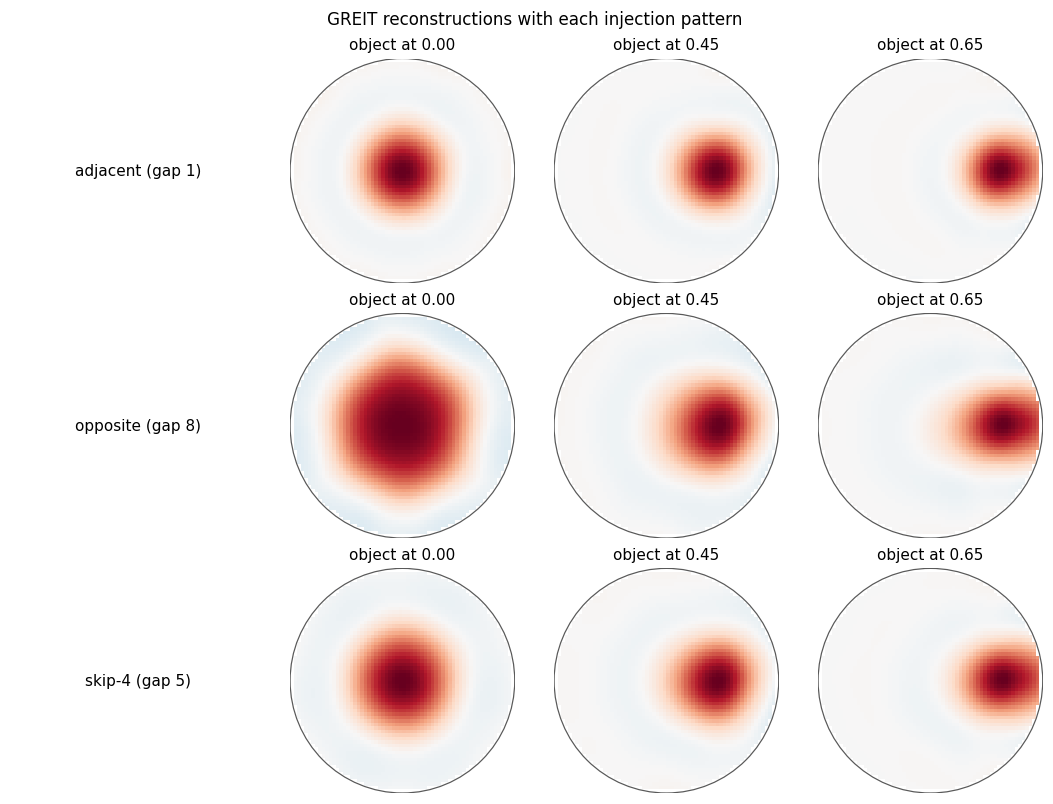

size                 visibility                
pattern  adjacent opposite skip_4   adjacent opposite skip_4
distance                                                    
0.00        0.403    0.652  0.486      4.318    2.127  3.362
0.45        0.363    0.441  0.405      4.973    3.904  4.355
0.65        0.349    0.391  0.373      5.216    4.333  4.630

In [5]:
figure, axes = plt.subplots(len(patterns), len(test_positions) + 1,
                            figsize=(2.4 * (len(test_positions) + 1), 2.4 * len(patterns)),
                            constrained_layout=True)
pattern_rows = []
for row, pattern in enumerate(patterns):
    solver, setup_seconds, _ = eit.prepare_method("greit", coarse_mesh, setups[pattern])
    axes[row, 0].axis("off")
    axes[row, 0].text(0.5, 0.5, eit.PATTERN_NAMES[pattern], ha="center", va="center",
                      fontsize=10, transform=axes[row, 0].transAxes)
    for column, distance in enumerate(test_positions, start=1):
        background_voltages, object_voltages, truth = measurements[(pattern, distance)]
        result = eit.reconstruct_image("greit", coarse_mesh, setups[pattern],
                                       object_voltages, background_voltages,
                                       prepared_solver=solver)
        eit.show_image(axes[row, column], result.scaled, title=f"object at {distance:.2f}")
        pattern_rows.append(dict(pattern=pattern, distance=distance,
                                 visibility=eit.contrast_to_noise(result.image, truth),
                                 **eit.score_image(truth, result.image)))
figure.suptitle("GREIT reconstructions with each injection pattern", fontsize=11)
figure.savefig(figures / "05_reconstructions.png")
plt.show()

pattern_scores = pd.DataFrame(pattern_rows)
pattern_scores.to_csv(tables / "05_pattern_scores.csv", index=False)
pattern_scores.pivot(index="distance", columns="pattern",
                     values=["size", "visibility"]).round(3)

This is the result I did not expect. Despite having the weakest signal and the most lopsided
sensitivity, **adjacent injection gives the tightest and clearest blobs at every position**.
Opposite injection produces much more signal but a noticeably blurrier picture.

The reason is that the 16 opposite injections all push current across the whole tank, so they end
up telling us very similar things — a lot of signal, but a lot of overlap. The 16 adjacent
injections each probe a different bit of the edge, so between them they carry more genuinely
independent information, and that is what sets how sharp the image can be.

One important caveat: this comparison assumes the noise scales with each pattern's own voltage
level. Real hardware has a fixed noise floor in volts, and since opposite and skip-4 produce much
larger voltages, they would gain ground on adjacent in a real system. Worth testing properly in a
later iteration.

## With noise added

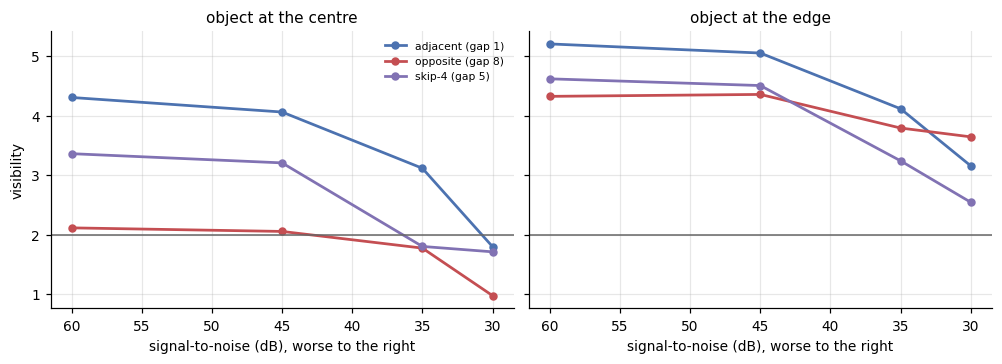

In [6]:
noise_levels = [60, 45, 35, 30]

pattern_noise_rows = []
for pattern in patterns:
    solver, setup_seconds, _ = eit.prepare_method("greit", coarse_mesh, setups[pattern])
    for distance in (0.0, 0.65):
        background_voltages, object_voltages, truth = measurements[(pattern, distance)]
        for noise_db in noise_levels:
            visibility_scores = []
            for repeat in range(5):
                generator = np.random.default_rng([eit.RANDOM_SEED, noise_db, repeat])
                noisy_background, noisy_object = eit.add_measurement_noise(
                    background_voltages, object_voltages, noise_db, generator)
                noisy_result = eit.reconstruct_image(
                    "greit", coarse_mesh, setups[pattern], noisy_object,
                    noisy_background, prepared_solver=solver)
                visibility_scores.append(eit.contrast_to_noise(noisy_result.image, truth))
            pattern_noise_rows.append(dict(pattern=pattern, distance=distance,
                                           noise_db=noise_db,
                                           visibility=float(np.mean(visibility_scores))))
pattern_noise = pd.DataFrame(pattern_noise_rows)
pattern_noise.to_csv(tables / "05_pattern_noise.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True, sharey=True)
for axis, distance in zip(axes, (0.0, 0.65)):
    for pattern in patterns:
        rows = pattern_noise[(pattern_noise.pattern == pattern)
                             & (pattern_noise.distance == distance)].sort_values("noise_db")
        axis.plot(rows.noise_db, rows.visibility, marker="o", ms=4.5, lw=1.8,
                  color=eit.PATTERN_COLOURS[pattern], label=eit.PATTERN_NAMES[pattern])
    axis.axhline(2.0, color="0.4", lw=1.0)
    axis.invert_xaxis()
    axis.set_xlabel("signal-to-noise (dB), worse to the right")
    axis.set_title(f"object at {'the centre' if distance == 0 else 'the edge'}")
    axis.grid(alpha=0.3)
axes[0].set_ylabel("visibility"); axes[0].legend(fontsize=7)
figure.savefig(figures / "05_pattern_noise.png")
plt.show()

Adjacent injection stays ahead for the **central** object at every noise level. But for the object
near the **edge** the lines cross: at 30 dB opposite injection (3.64) overtakes adjacent (3.16).

That is a small hint of the caveat above. Opposite injection has more signal to spare, so it loses
ground more slowly as noise grows — and this is with the noise still scaled to each pattern's own
voltages, which is the setup least favourable to it. With a fixed noise floor the crossover would
come sooner and be larger.

---

# Task 6 — pulling it together

## The three methods

In [7]:
method_summary = pd.DataFrame([
    dict(method="Back-projection",
         good="fastest to set up by a long way; almost no false halo; never unstable",
         bad="blob about three times too big; worst at placing the object; "
             "image brightness is on an arbitrary scale",
         use_for="a quick look while setting things up"),
    dict(method="Gauss-Newton",
         good="sharpest blob and best position accuracy on clean data",
         bad="strongest false halo around objects; falls apart fastest as noise grows; "
             "needs its smoothing setting tuned",
         use_for="good measurement hardware, objects near the edge"),
    dict(method="GREIT",
         good="roundest blobs, modest halo, copes best with noise, most consistent "
              "across the tank",
         bad="blurrier than Gauss-Newton on clean data; slowest to set up",
         use_for="a sensible default for most situations"),
])
method_summary.to_csv(tables / "05_method_summary.csv", index=False)
pd.set_option("display.max_colwidth", None)
method_summary.set_index("method").T

method,Back-projection,Gauss-Newton,GREIT
good,fastest to set up by a long way; almost no false halo; never unstable,sharpest blob and best position accuracy on clean data,"roundest blobs, modest halo, copes best with noise, most consistent across the tank"
bad,blob about three times too big; worst at placing the object; image brightness is on an arbitrary scale,strongest false halo around objects; falls apart fastest as noise grows; needs its smoothing setting tuned,blurrier than Gauss-Newton on clean data; slowest to set up
use_for,a quick look while setting things up,"good measurement hardware, objects near the edge",a sensible default for most situations


In [8]:
pattern_summary = pd.DataFrame([
    dict(pattern="adjacent (gap 1)",
         current="stays in a thin band near the edge",
         good="sharpest and clearest images at every position in these simulations; "
              "simplest switching hardware",
         bad="by far the most lopsided sensitivity and the smallest signal, "
             "especially for objects in the middle",
         use_for="clean measurements, objects near the edge"),
    dict(pattern="opposite (gap 8)",
         current="straight across the tank",
         good="most even sensitivity, several times more signal for a central object, "
              "and much larger voltages overall",
         bad="blurriest images here, because its 16 injections overlap heavily and "
             "repeat much of the same information",
         use_for="noisy hardware, or objects expected in the middle"),
    dict(pattern="skip-4 (gap 5)",
         current="part way across",
         good="close to opposite on sensitivity and signal while staying much closer "
              "to adjacent on image sharpness",
         bad="not the best at any single thing",
         use_for="a reasonable all-round choice when you do not know where objects will be"),
])
pattern_summary.to_csv(tables / "05_pattern_summary.csv", index=False)
pattern_summary.set_index("pattern").T

pattern,adjacent (gap 1),opposite (gap 8),skip-4 (gap 5)
current,stays in a thin band near the edge,straight across the tank,part way across
good,sharpest and clearest images at every position in these simulations; simplest switching hardware,"most even sensitivity, several times more signal for a central object, and much larger voltages overall",close to opposite on sensitivity and signal while staying much closer to adjacent on image sharpness
bad,"by far the most lopsided sensitivity and the smallest signal, especially for objects in the middle","blurriest images here, because its 16 injections overlap heavily and repeat much of the same information",not the best at any single thing
use_for,"clean measurements, objects near the edge","noisy hardware, or objects expected in the middle",a reasonable all-round choice when you do not know where objects will be


## Settings used throughout

| setting | value |
|---|---|
| tank | circle of radius 1 |
| electrodes | 16, evenly spaced |
| background conductivity | 1.0 |
| simulation mesh | ~3500 triangles |
| reconstruction mesh | ~1080 triangles (deliberately coarser) |
| standard object | circle, radius 0.15, conductivity 2.0 |
| imaging | difference imaging (empty tank vs. tank with object) |
| image size | 64 × 64 |
| noise | random noise added to both sets of voltages, 60 / 45 / 35 / 30 dB |
| repeats | 5 random noise runs per level |
| random seed | 2026, so every number repeats exactly |

## Overall conclusions

- Nothing recovers the true size of an object. Every method, every pattern, every position gives a
  blob at least twice too big, and small objects are exaggerated most.
- **GREIT** is the best default: nearly as sharp as Gauss-Newton, rounder blobs, less ringing and
  clearly better once noise is involved.
- **Adjacent** injection produced the sharpest images in every test here, which surprised me given
  it has the weakest signal. More independent information beats more signal, at least when the data
  are clean.
- Two objects have to be about two diameters apart to be seen as two.
- Objects in the middle of the tank are always the hardest: weakest signal, biggest blob, first to
  disappear under noise.

## Limits of this study

- Everything is 2-D, so the results are more optimistic than a real 3-D tank.
- The electrodes are treated as points, with no contact resistance or physical size.
- The tank shape and electrode positions are known exactly, which is never true in practice.
- Only difference imaging was tested, not absolute imaging.
- The noise level was scaled to each pattern's own voltages, which understates how well opposite and
  skip-4 would do against a real fixed noise floor. This is the main thing I would fix next.

---

**Reference:** Benyuan Liu et al., "pyEIT: A python based framework for Electrical Impedance
Tomography", *SoftwareX* 7 (2018), 304–308.